In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# DataSet Link: https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset

In [3]:
df = pd.read_csv('data/AmesHousing.csv')

In [4]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
df = df.drop(['PID','Order'],axis=1)

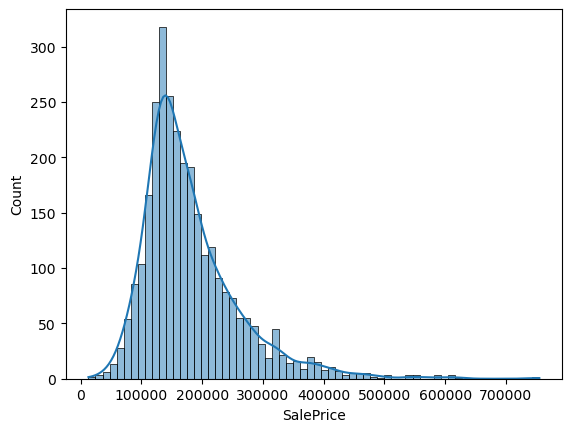

In [7]:
sns.histplot(
    data = df,
    x = 'SalePrice',
    kde = True,
    line_kws={'color': 'red'}
)
plt.show()

In [8]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0 ].sort_values(ascending=False) 

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

In [9]:
df['Pool QC'].unique()

array([nan, 'Ex', 'Gd', 'TA', 'Fa'], dtype=object)

In [10]:
df[df['Pool Area'] == 0]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


Reasoning for Dropping the Pool QC Feature:
Upon cross-referencing the 2,917 missing values in the Pool QC (Pool Quality) column with the Pool Area feature, we observed exactly 2,917 rows where the Pool Area is 0. This confirms that NaN in Pool QC does not represent lost data, but rather indicates the absence of a pool.
Since only 13 out of 2,930 houses (less than 0.5% of the dataset) actually have a pool, the Pool QC feature suffers from near-zero variance. Retaining this feature would provide almost no information gain for our Decision Tree model and could potentially lead to overfitting on those 13 specific instances. Furthermore, the Pool Area column already captures both the existence and the size of the pool, making Pool QC completely redundant. Therefore, dropping the Pool QC column is the optimal step to reduce dimensionality and noise.

In [11]:
df = df.drop('Pool QC',axis=1)

In [12]:
df['Misc Val'].unique()

array([    0, 12500,   500,   700,   400,   450,  1500,   300,   600,
        1200,  3500,  2000,  2500,    54,    80,   490,   480,   350,
         650,   900,   800,   750,  1400,  6500,  1150,  1000,  4500,
        3000,   560,  1300,  8300, 15500, 17000,  1512,   455,   460,
         620,   420])

In [13]:
df[df['Misc Val'] == 0]['Misc Feature'].value_counts()

Misc Feature
Shed    2
Othr    1
Name: count, dtype: int64

In [14]:
df['Misc Feature'].unique()

array([nan, 'Gar2', 'Shed', 'Othr', 'Elev', 'TenC'], dtype=object)

In [15]:
df[df['Misc Val'] == 0]['Misc Feature']

0       NaN
1       NaN
3       NaN
4       NaN
5       NaN
       ... 
2924    NaN
2925    NaN
2926    NaN
2928    NaN
2929    NaN
Name: Misc Feature, Length: 2827, dtype: object

Upon examining the Misc Feature column, we observed 2,824 missing values. This means over 96% of the properties in our dataset lack any miscellaneous features. Although there are 3 edge cases where a feature exists (e.g., a Shed) but its monetary impact (Misc Value) is recorded as 0, the overarching statistical reality remains unchanged. Similarly, the Alley feature contains 2,732 missing values (indicating no alley access for ~93% of homes). Both of these columns suffer from near-zero variance. Feeding features where over 90% of the observations belong to a single category (or represent the absence of the feature) into a Decision Tree Regressor provides negligible information gain and drastically increases the risk of overfitting to noise. Therefore, dropping both Misc Feature and Alley is the most logical step to streamline our model.

In [16]:
df = df.drop(['Misc Feature','Alley'],axis=1)

In [17]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0 ].sort_values(ascending=False)

Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
BsmtFin SF 2         1
Garage Cars          1
Garage Area          1
dtype: int64

In [18]:
df['Fence'].unique()

array([nan, 'MnPrv', 'GdPrv', 'GdWo', 'MnWw'], dtype=object)

In [19]:
df = df.drop('Fence',axis=1)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   object 
 2   Lot Frontage     2440 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   object 
 5   Lot Shape        2930 non-null   object 
 6   Land Contour     2930 non-null   object 
 7   Utilities        2930 non-null   object 
 8   Lot Config       2930 non-null   object 
 9   Land Slope       2930 non-null   object 
 10  Neighborhood     2930 non-null   object 
 11  Condition 1      2930 non-null   object 
 12  Condition 2      2930 non-null   object 
 13  Bldg Type        2930 non-null   object 
 14  House Style      2930 non-null   object 
 15  Overall Qual     2930 non-null   int64  
 16  Overall Cond     2930 non-null   int64  
 17  Year Built    

In [21]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0 ].sort_values(ascending=False)

Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Finish      159
Garage Yr Blt      159
Garage Cond        159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
Total Bsmt SF        1
BsmtFin SF 2         1
Bsmt Unf SF          1
BsmtFin SF 1         1
Electrical           1
Garage Area          1
Garage Cars          1
dtype: int64

In [22]:
df[df['Mas Vnr Area'] == 0]['Mas Vnr Type'].value_counts(dropna = False)

Mas Vnr Type
NaN        1745
BrkFace       2
Stone         1
Name: count, dtype: int64

In [23]:
df['Mas Vnr Type'].unique()

array(['Stone', nan, 'BrkFace', 'BrkCmn', 'CBlock'], dtype=object)

Reasoning for Retaining and Imputing Mas Vnr Type and Mas Vnr Area:
Unlike the previously dropped features, Mas Vnr Type (Masonry Veneer Type) is only missing in about 61% of the dataset. This leaves approximately 40% of the properties (over 1,100 houses) with a specific masonry veneer (e.g., Brick Face, Stone). Since exterior material is a significant factor in property valuation, retaining this feature provides valuable information gain for our Decision Tree model. The missing values structurally indicate the absence of a masonry veneer. Therefore, we will retain both features and apply imputation: missing categorical values in Mas Vnr Type will be filled with 'None', and corresponding missing numerical values in Mas Vnr Area will be filled with 0.

In [24]:
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna('None')
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

In [25]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0 ].sort_values(ascending=False)

Fireplace Qu      1422
Lot Frontage       490
Garage Finish      159
Garage Cond        159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
BsmtFin Type 1      80
Bsmt Cond           80
Bsmt Qual           80
Bsmt Half Bath       2
Bsmt Full Bath       2
Total Bsmt SF        1
BsmtFin SF 2         1
Bsmt Unf SF          1
BsmtFin SF 1         1
Electrical           1
Garage Area          1
Garage Cars          1
dtype: int64

In [26]:
df[df['Fireplaces'] == 0]['Fireplace Qu'].value_counts(dropna = False)

Fireplace Qu
NaN    1422
Name: count, dtype: int64

Reasoning for Imputing Fireplace Qu:
By cross-referencing with the Fireplaces feature, we confirmed that all 1,422 missing values in Fireplace Qu correspond exactly to houses with 0 fireplaces. Since roughly half of the properties in the dataset possess a fireplace, this feature holds high variance and provides significant information gain for predicting house prices. Therefore, dropping it would result in valuable data loss. Instead, we will retain the feature and impute the structurally missing values with the string 'None'.

In [27]:
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

In [28]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0 ].sort_values(ascending=False)

Lot Frontage      490
Garage Yr Blt     159
Garage Qual       159
Garage Cond       159
Garage Finish     159
Garage Type       157
Bsmt Exposure      83
BsmtFin Type 2     81
Bsmt Cond          80
Bsmt Qual          80
BsmtFin Type 1     80
Bsmt Full Bath      2
Bsmt Half Bath      2
Electrical          1
Bsmt Unf SF         1
BsmtFin SF 2        1
BsmtFin SF 1        1
Total Bsmt SF       1
Garage Area         1
Garage Cars         1
dtype: int64

Reasoning for Imputing Lot Frontage:
Unlike the previous categorical features where a missing value indicated the physical absence of a structure (e.g., no pool, no fireplace), the missing values in Lot Frontage represent true missing data. Every property inherently has a lot and street frontage, which is confirmed by the presence of large values in their respective Lot Area column. Since lot sizes, street layouts, and zoning regulations are highly dependent on the location of the house, filling these missing values with a global dataset average would distort the data. Instead, we implemented a smarter imputation strategy: we grouped the properties by their Neighborhood and imputed the missing Lot Frontage values using the median frontage of that specific neighborhood. This approach preserves the local architectural characteristics and ensures a more accurate representation for our Decision Tree Regressor.

In [29]:
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

In [30]:
def show_nulls(dataframe):
    null_counts = df.isnull().sum()
    return null_counts[null_counts > 0 ].sort_values(ascending=False)

In [31]:
show_nulls(df)

Garage Finish     159
Garage Yr Blt     159
Garage Qual       159
Garage Cond       159
Garage Type       157
Bsmt Exposure      83
BsmtFin Type 2     81
Bsmt Qual          80
BsmtFin Type 1     80
Bsmt Cond          80
Lot Frontage        3
Bsmt Full Bath      2
Bsmt Half Bath      2
Electrical          1
Bsmt Unf SF         1
BsmtFin SF 2        1
BsmtFin SF 1        1
Total Bsmt SF       1
Garage Area         1
Garage Cars         1
dtype: int64

In [32]:
keyword = 'Garage'
target_cols = [col for col in df.columns if keyword in col]
categorical_cols = [col for col in target_cols if df[col].dtype == 'object']
numeric_cols = [col for col in target_cols if df[col].dtype != 'object']
print(f"--- {keyword.upper()} FEATURES CROSS-VALIDATION ---\n")
for cat_col in categorical_cols:
    print(f"If '{cat_col}' is NULL;")
    
    missing_rows = df[df[cat_col].isnull()]
    
    for num_col in numeric_cols:
        value_distribution = missing_rows[num_col].value_counts(dropna=False)
        
        majority_value = value_distribution.index[0]
        count = value_distribution.values[0]
        
        print(f"  -> Majority value for '{num_col}': {majority_value} (Count: {count})")
    
    print("-" * 50)

--- GARAGE FEATURES CROSS-VALIDATION ---

If 'Garage Type' is NULL;
  -> Majority value for 'Garage Yr Blt': nan (Count: 157)
  -> Majority value for 'Garage Cars': 0.0 (Count: 157)
  -> Majority value for 'Garage Area': 0.0 (Count: 157)
--------------------------------------------------
If 'Garage Finish' is NULL;
  -> Majority value for 'Garage Yr Blt': nan (Count: 159)
  -> Majority value for 'Garage Cars': 0.0 (Count: 157)
  -> Majority value for 'Garage Area': 0.0 (Count: 157)
--------------------------------------------------
If 'Garage Qual' is NULL;
  -> Majority value for 'Garage Yr Blt': nan (Count: 159)
  -> Majority value for 'Garage Cars': 0.0 (Count: 157)
  -> Majority value for 'Garage Area': 0.0 (Count: 157)
--------------------------------------------------
If 'Garage Cond' is NULL;
  -> Majority value for 'Garage Yr Blt': nan (Count: 159)
  -> Majority value for 'Garage Cars': 0.0 (Count: 157)
  -> Majority value for 'Garage Area': 0.0 (Count: 157)
-------------------

Cross-Validation and Imputation Strategy for Garage Features
The cross-validation output clearly demonstrates a structural pattern: whenever the categorical garage features (such as Garage Type, Garage Finish, Garage Qual, and Garage Cond) are missing, the corresponding numerical features (Garage Cars and Garage Area) predominantly hold a value of 0.0, and the Garage Yr Blt is NaN. This confirms our hypothesis that these missing values are not random data losses, but rather indicate the physical absence of a garage on the property. Since the existence and capacity of a garage are critical variables for price prediction, dropping them would cause significant information loss. Instead, we will apply a dynamic imputation strategy: missing values in categorical columns will be filled with the string 'None' to explicitly represent "No Garage", and missing values in numerical columns will be filled with 0.

In [33]:
for col in target_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('None')
    else:
        df[col] = df[col].fillna(0)
print(f"Missing values in {keyword} features have been successfully imputed.")

Missing values in Garage features have been successfully imputed.


In [34]:
show_nulls(df)

Bsmt Exposure     83
BsmtFin Type 2    81
Bsmt Cond         80
BsmtFin Type 1    80
Bsmt Qual         80
Lot Frontage       3
Bsmt Half Bath     2
Bsmt Full Bath     2
BsmtFin SF 1       1
Bsmt Unf SF        1
BsmtFin SF 2       1
Electrical         1
Total Bsmt SF      1
dtype: int64

In [35]:
keyword = 'Bsmt'
target_cols = [col for col in df.columns if keyword in col]
categorical_cols = [col for col in target_cols if df[col].dtype == 'object']
numeric_cols = [col for col in target_cols if df[col].dtype != 'object']
print(f"--- {keyword.upper()} FEATURES CROSS-VALIDATION ---\n")
for cat_col in categorical_cols:
    print(f"If '{cat_col}' is NULL;")
    
    missing_rows = df[df[cat_col].isnull()]
    
    for num_col in numeric_cols:
        value_distribution = missing_rows[num_col].value_counts(dropna=False)
        
        majority_value = value_distribution.index[0]
        count = value_distribution.values[0]
        
        print(f"  -> Majority value for '{num_col}': {majority_value} (Count: {count})")
    
    print("-" * 50)

--- BSMT FEATURES CROSS-VALIDATION ---

If 'Bsmt Qual' is NULL;
  -> Majority value for 'BsmtFin SF 1': 0.0 (Count: 79)
  -> Majority value for 'BsmtFin SF 2': 0.0 (Count: 79)
  -> Majority value for 'Bsmt Unf SF': 0.0 (Count: 79)
  -> Majority value for 'Total Bsmt SF': 0.0 (Count: 79)
  -> Majority value for 'Bsmt Full Bath': 0.0 (Count: 78)
  -> Majority value for 'Bsmt Half Bath': 0.0 (Count: 78)
--------------------------------------------------
If 'Bsmt Cond' is NULL;
  -> Majority value for 'BsmtFin SF 1': 0.0 (Count: 79)
  -> Majority value for 'BsmtFin SF 2': 0.0 (Count: 79)
  -> Majority value for 'Bsmt Unf SF': 0.0 (Count: 79)
  -> Majority value for 'Total Bsmt SF': 0.0 (Count: 79)
  -> Majority value for 'Bsmt Full Bath': 0.0 (Count: 78)
  -> Majority value for 'Bsmt Half Bath': 0.0 (Count: 78)
--------------------------------------------------
If 'Bsmt Exposure' is NULL;
  -> Majority value for 'BsmtFin SF 1': 0.0 (Count: 82)
  -> Majority value for 'BsmtFin SF 2': 0.0 (C

In [36]:
for col in target_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('None')
    else:
        df[col] = df[col].fillna(0)
print(f"Missing values in {keyword} features have been successfully imputed.")

Missing values in Bsmt features have been successfully imputed.


In [37]:
df = df.dropna()

In [38]:
show_nulls(df)

Series([], dtype: int64)

In [39]:
df.shape

(2926, 76)

In [40]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.to_list()
correlation_matrix = df[numeric_cols].corr()
sale_price_corr = correlation_matrix['SalePrice'].sort_values(ascending = False)
print('Top 10 Features with the Highest Correlation with SalePrice')
print(sale_price_corr[1:11])

Top 10 Features with the Highest Correlation with SalePrice
Overall Qual      0.799429
Gr Liv Area       0.707331
Garage Cars       0.649201
Garage Area       0.641455
Total Bsmt SF     0.633643
1st Flr SF        0.621581
Year Built        0.558632
Full Bath         0.546945
Year Remod/Add    0.533236
Mas Vnr Area      0.502178
Name: SalePrice, dtype: float64


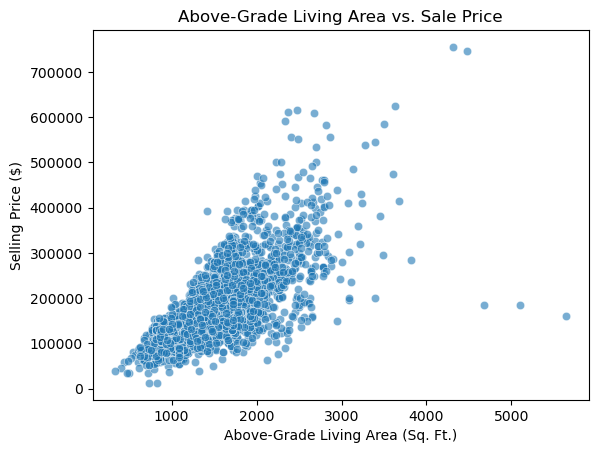

In [41]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df, alpha=0.6)
plt.title('Above-Grade Living Area vs. Sale Price')
plt.xlabel('Above-Grade Living Area (Sq. Ft.)')
plt.ylabel('Selling Price ($)')
plt.show()

Visual Interpretation:
The scatter plot clearly illustrates a strong, positive linear relationship between the above-grade living area and the sale price. As the square footage of the property increases, the sale price consistently follows an upward trend. However, a notable anomaly is visible in the bottom-right corner of the plot: a few exceptional properties with living areas exceeding 4,000 square feet were sold well below the expected price trend (under $200,000). These extreme outliers warrant careful consideration before modeling, as they pose a potential risk, particularly for non-tree-based algorithms.

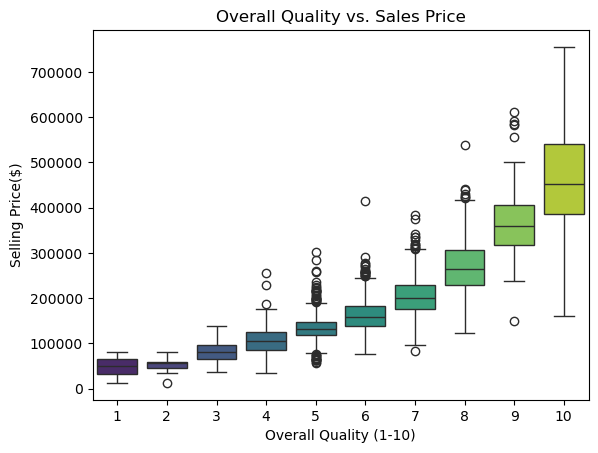

In [42]:
sns.boxplot(x='Overall Qual', y='SalePrice', data=df, palette='viridis')
plt.title('Overall Quality vs. Sales Price')
plt.xlabel('Overall Quality (1-10)')
plt.ylabel('Selling Price($)')
plt.show()

Visual Interpretation:
The box plot highlights the immense impact of the overall material and finish quality on property valuation. As the quality rating progresses from 1 to 10, the increase in sale price is not merely linear, but rather exponential. Specifically, for properties rated 7 and above, the premium added to the price for each incremental quality point (indicated by the vertical distance between boxes) is substantially larger than in the lower-quality tiers. Furthermore, the plot reveals outliers across segments: there are exceptionally high-priced sales in the lower-to-mid quality tiers (e.g., ratings 4, 5, and 6), as well as unexpectedly low-priced properties within the premium quality tiers (e.g., ratings 8 and 9).

In [43]:
print("Top 5 Features with the Strongest Negative Correlation with SalePrice:")
print(sale_price_corr.tail(5))

Top 5 Features with the Strongest Negative Correlation with SalePrice:
Low Qual Fin SF   -0.037626
MS SubClass       -0.086072
Overall Cond      -0.101481
Kitchen AbvGr     -0.119778
Enclosed Porch    -0.128674
Name: SalePrice, dtype: float64


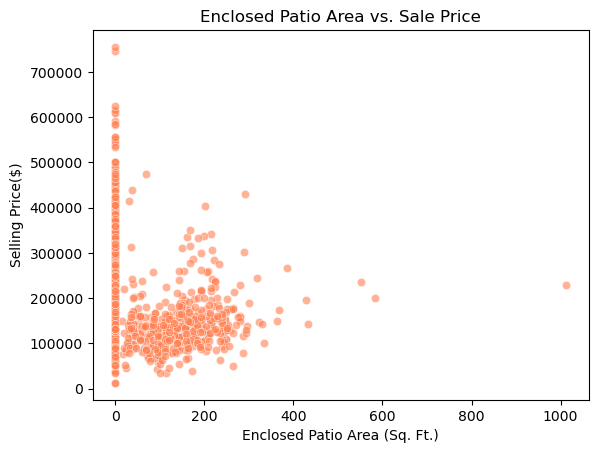

In [44]:
sns.scatterplot(x='Enclosed Porch', y='SalePrice', data=df, alpha=0.6, color='coral')
plt.title('Enclosed Patio Area vs. Sale Price')
plt.xlabel('Enclosed Patio Area (Sq. Ft.)')
plt.ylabel('Selling Price($)')
plt.show()

Visual Interpretation:
The scatter plot visualizes the negative correlation between the enclosed patio (porch) area and the sale price. The most striking observation is that the vast majority of data points cluster strictly at zero (indicating no enclosed patio), and this subset contains all of the highest-priced luxury properties. For houses that do feature an enclosed patio (x-axis > 0), the sale prices are largely confined to the lower and middle tiers (mostly under $300,000), regardless of the patio's size. This confirms the domain knowledge that enclosed porches are predominantly architectural features of older, less expensive homes, whereas modern, high-value properties generally lack this addition.

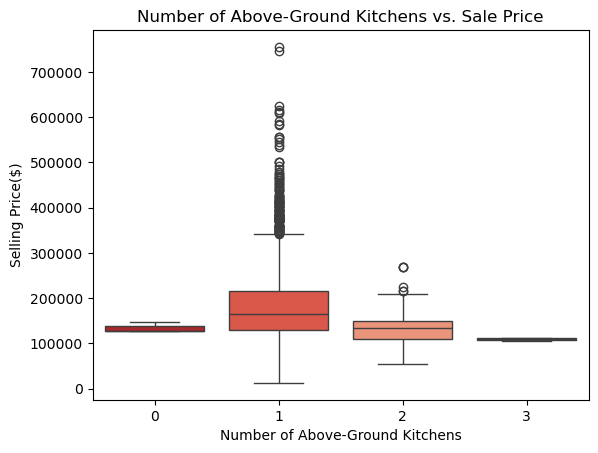

In [45]:
sns.boxplot(x='Kitchen AbvGr', y='SalePrice', data=df, palette='Reds_r')
plt.title('Number of Above-Ground Kitchens vs. Sale Price')
plt.xlabel('Number of Above-Ground Kitchens')
plt.ylabel('Selling Price($)')
plt.show()

Visual Interpretation:
The box plot clearly summarizes the inverse relationship between the number of above-ground kitchens and property value. As expected, properties with exactly 1 kitchen—representing standard single-family residential homes—boast the highest median price and the widest price distribution, heavily populated with high-end outliers. However, when the number of kitchens increases to 2, the price box shifts dramatically downward. Properties with multiple kitchens typically indicate multi-family dwellings (such as duplexes) or older homes converted into rental units, which generally command significantly lower market values than premium single-family homes. This structural reality perfectly explains the strong negative correlation observed.